# Easy CNN on MNIST

**Goal:** train a small CNN with minimum code. Run the notebook from top to bottom, then try the small experiments at the end.

## 1. Setup

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using:', DEVICE)

Using: cpu


## 2. Load MNIST

`ToTensor()` changes each image into numbers between 0 and 1. A `DataLoader` gives us small batches of images.

In [2]:
transform = transforms.ToTensor()
train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

images, labels = next(iter(train_loader))
print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)

100%|██████████| 9.91M/9.91M [00:30<00:00, 323kB/s] 


Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 3. Look at a batch

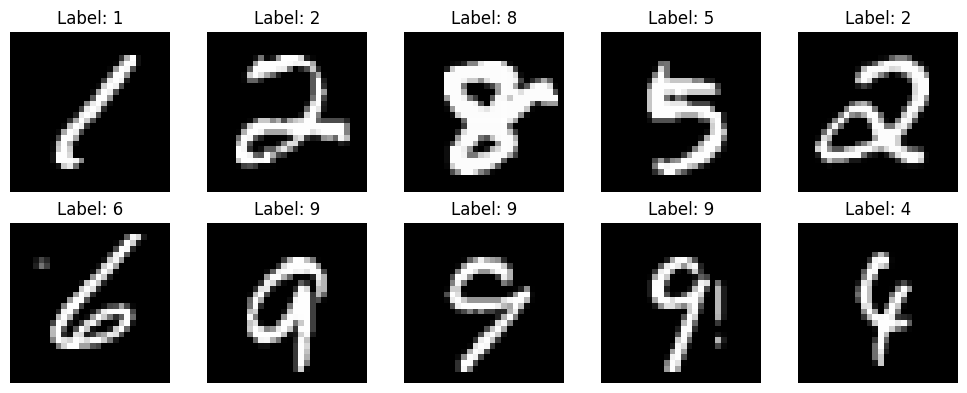

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i, axis in enumerate(ax.ravel()):
    axis.imshow(images[i, 0], cmap='gray')
    axis.set_title(f'Label: {labels[i].item()}')
    axis.axis('off')
plt.tight_layout()

## 4. Build a tiny CNN

The model has two repeating blocks: `Convolution → ReLU → Pooling`, then a final classifier with ten outputs.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(16 * 5 * 5, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

model = SimpleCNN().to(DEVICE)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=400, out_features=10, bias=True)
)


## 5. Train the model

This is the familiar loop: predict → measure error → send blame backward → update the model.

In [5]:
def train_one_epoch():
    model.train()
    total_loss = 0
    for batch_images, batch_labels in train_loader:
        batch_images, batch_labels = batch_images.to(DEVICE), batch_labels.to(DEVICE)
        predictions = model(batch_images)
        loss = loss_function(predictions, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

epochs = 3
losses = []
for epoch in range(epochs):
    epoch_loss = train_one_epoch()
    losses.append(epoch_loss)
    print(f'Epoch {epoch + 1}/{epochs} — loss: {epoch_loss:.3f}')

Epoch 1/3 — loss: 0.330
Epoch 2/3 — loss: 0.099
Epoch 3/3 — loss: 0.078


## 6. Visualize learning

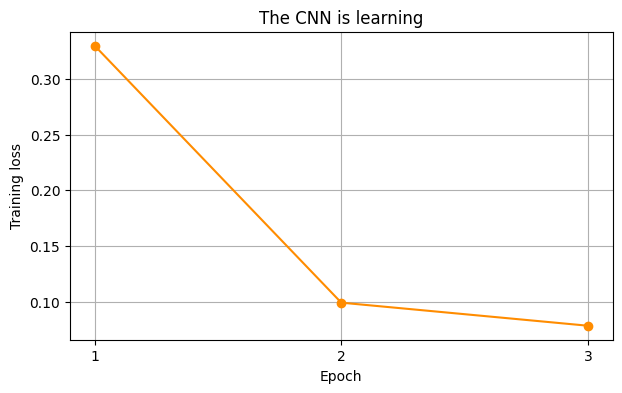

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), losses, marker='o', color='darkorange')
plt.xlabel('Epoch'); plt.ylabel('Training loss'); plt.title('The CNN is learning')
plt.xticks(range(1, epochs + 1)); plt.grid(True); plt.show()

## 7. Test on unseen images

In [7]:
model.eval()
correct = total = 0
all_predictions, all_labels, all_images = [], [], []
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        scores = model(batch_images.to(DEVICE))
        predicted_labels = scores.argmax(dim=1).cpu()
        correct += (predicted_labels == batch_labels).sum().item()
        total += batch_labels.size(0)
        all_predictions.extend(predicted_labels.tolist())
        all_labels.extend(batch_labels.tolist())
        all_images.extend(batch_images[:, 0])

accuracy = correct / total
print(f'Test accuracy: {accuracy:.1%}')

Test accuracy: 97.8%


## 8. Inspect predictions

Correct and incorrect examples help us understand the model—not just its accuracy number.

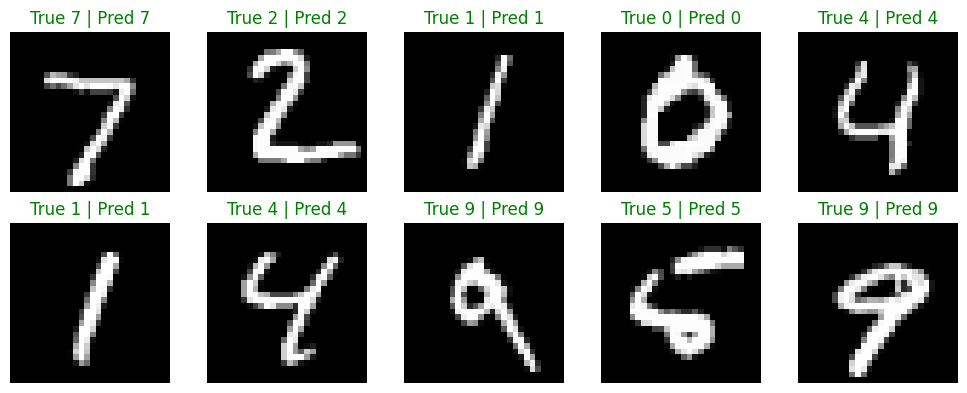

In [8]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i, axis in enumerate(ax.ravel()):
    axis.imshow(all_images[i], cmap='gray')
    truth, prediction = all_labels[i], all_predictions[i]
    color = 'green' if truth == prediction else 'red'
    axis.set_title(f'True {truth} | Pred {prediction}', color=color)
    axis.axis('off')
plt.tight_layout()

## 9. Try one easy experiment

Change **one** thing, then run again:

- change `epochs = 3` to `5`;
- change `batch_size=64` to `128`;
- change the first `Conv2d(1, 8, 3)` to `Conv2d(1, 16, 3)`.

Write down: Did training loss fall? Did test accuracy improve?